In [1]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


In [4]:
data_folder = '/Users/benny/swc/agents/data/agents_seed_17_full_logs'
solo_files = identify_filepaths.get_relative_paths('Solo', data_folder)

df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

IntProgress(value=0, max=43)

filepath: /Users/benny/swc/agents/data/agents_seed_17_full_logs/260416_1/2026-04-29_13-30-52_M18_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/agents_seed_17_full_logs/260417_1/2026-04-29_11-42-49_M19_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/agents_seed_17_full_logs/260417_2/2026-04-29_08-18-54_M20_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/agents_seed_17_full_logs/260417_3/2026-04-29_06-54-23_M21_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/agents_seed_17_full_logs/260417_4/2026-04-28_19-57-43_M22_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/agents_seed_17_full_logs/260418_1/2026-04-28_18-35-32_M23_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/agents_seed_17_full_logs/260418_3/2026-04-28_15-45-16_M25_Solo.json

In [5]:
dropped_trials = 1

In [6]:
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 539
First trial end event found at index: 545
First trial end event found at index: 539
First trial end event found at index: 555
First trial end event found at index: 556
First trial end event found at index: 557
First trial end event found at index: 553
First trial end event found at index: 547
First trial end event found at index: 576
First trial end event found at index: 547
First trial end event found at index: 518
First trial end event found at index: 519
First trial end event found at index: 545
First trial end event found at index: 553
First trial end event found at index: 578
First trial end event found at index: 546
First trial end event found at index: 533
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 538
First trial end event found at index: 538
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at ind

In [7]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

**CURRENT PLAN**

1. Plot session trajectories for each file

2. P(H) across walls

2. High choices across octagon space with first seen

3. Centrality (I guess probably visible from session trajectories)

4. Relate to parameters


### Parameter value extraction

In [8]:
import agent_analysis.functions.preprocessing as prep

In [10]:
_, step_penalties, _ = prep.extract_step_penalties(data_folder, yaml_filename=None)

In [11]:
len(step_penalties)

43

## Session trajectories

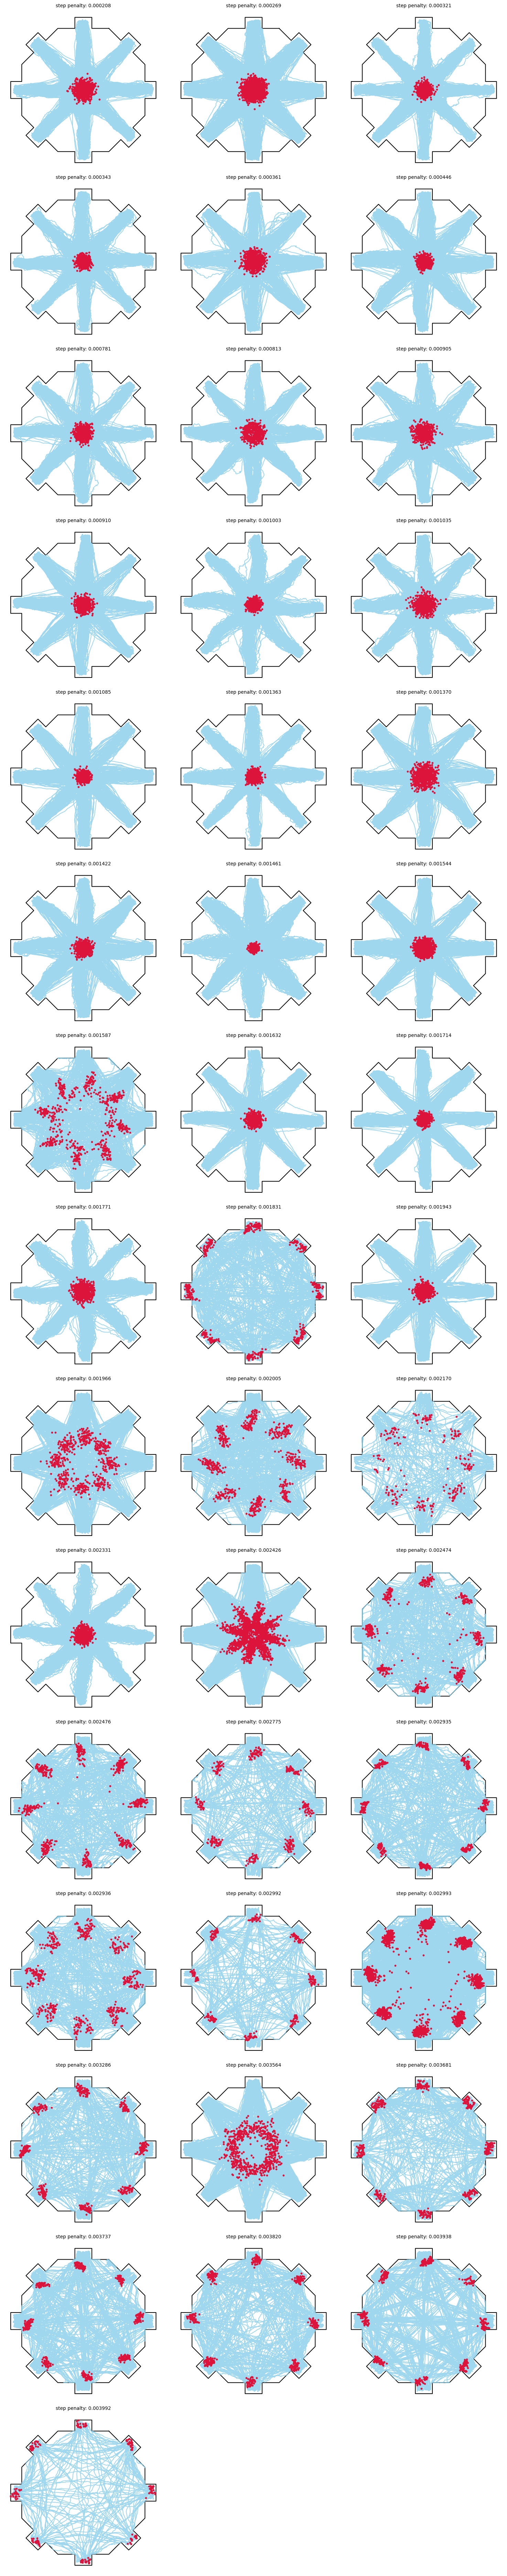

In [12]:
import matplotlib.pyplot as plt

num_lists = len(dfs_cropped)
num_cols = 3
num_rows = (num_lists + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))

axes = axes.flatten()

# Create list of (penalty, trial_list) and sort by penalty
sorted_trials = sorted(zip(step_penalties, dfs_cropped), key=lambda x: x[0])

for i, (penalty, trial_list) in enumerate(sorted_trials):
    ax = plot_octagon.plot_octagon(ax=axes[i])
    plot_trajectory.plot_session_trajectory(ax, trial_list, colour_player_1='skyblue', alpha=0.8, slice_onset_markers=True)
    plot_trajectory.mark_session_slice_onsets(ax, trial_list, chosen_player=0, color='crimson')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_title(f'step penalty: {penalty:.6f}', fontsize=10)

for j in range(num_lists, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## P(High) across walls

In [42]:
analysis_results = {
    session_id: {

            # trial list and filtered trial indices
            'trial_lists': {
                'full_session': None
            },

            # chosen wall numbers and whether high or low
            'choice_data' : {
                'wall_numbers': None,
                'chose_high': None,
                'probability_chose_high': None  # array of values from walls 1 to 8
            }
            

        }
    for session_id in np.arange(len(trial_lists))
}

In [43]:
# assign trial lists

for session_id in analysis_results.keys():

    print(f"\n\nProcessing session: {session_id}\n\n")
    player_data = analysis_results[session_id]
    trial_list = trial_lists[session_id]
    print(f"Number of trials in full session: {len(trial_list)}")


    player_data['trial_lists']['full_session'] = trial_list



Processing session: 0


Number of trials in full session: 467


Processing session: 1


Number of trials in full session: 666


Processing session: 2


Number of trials in full session: 588


Processing session: 3


Number of trials in full session: 533


Processing session: 4


Number of trials in full session: 1929


Processing session: 5


Number of trials in full session: 568


Processing session: 6


Number of trials in full session: 507


Processing session: 7


Number of trials in full session: 521


Processing session: 8


Number of trials in full session: 511


Processing session: 9


Number of trials in full session: 622


Processing session: 10


Number of trials in full session: 944


Processing session: 11


Number of trials in full session: 1998


Processing session: 12


Number of trials in full session: 500


Processing session: 13


Number of trials in full session: 1800


Processing session: 14


Number of trials in full session: 480


Processing session: 15


Numbe

In [44]:
for session_id in analysis_results.keys():

    player_data = analysis_results[session_id]
    trial_list = player_data['trial_lists']['full_session']

    player_data['choice_data']['wall_numbers'] = get_indices.get_chosen_walls(trial_list).astype(int)
    player_data['choice_data']['chose_high'] = get_indices.was_high_wall_chosen(trial_list)


    # print(len(player_data['choice_data']['chose_high']))

In [49]:
for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    wall_numbers = player_data['choice_data']['wall_numbers']
    chose_high = player_data['choice_data']['chose_high']

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    mask = counts > 4  # Ensure at least 5 trials per wall to calculate probability
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    player_data['choice_data']['probability_chose_high'] = wall_probabilities

    chose_high_total = len(chose_high[chose_high==True])
    session_len = len(player_data['trial_lists']['full_session'])
    if session_len > 0:
        p_high = chose_high_total/session_len
    else:
        p_high = np.nan
        
    player_data['choice_data']['p_high_model'] = p_high

In [50]:
wall_number_list = [analysis_results[session_id]['choice_data']['wall_numbers']
 for session_id in analysis_results
 ]
chose_high_list = [analysis_results[session_id]['choice_data']['chose_high']
 for session_id in analysis_results
 ]


wall_numbers = np.concatenate(wall_number_list).astype(int)
chose_high = np.concatenate(chose_high_list)

In [51]:
# more efficient code with vectorised functions

wall_probabilities = np.full(8, np.nan)

# specify min bins == highest integer value + 1
# slice from index 1 because 0 will always be counted, but is not relevant
counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

mask = counts > 0  # Avoid division by zero
wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

In [22]:
# get error bars

standard_error = np.sqrt((wall_probabilities * (1 - wall_probabilities)) / len(wall_number_list))

### example model

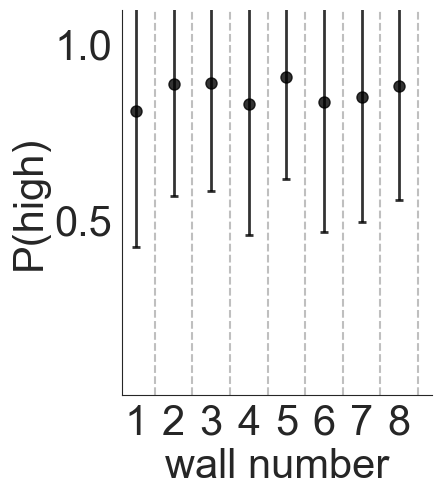

In [23]:
wall_numbers = np.arange(1,9)
wall_probabilities = wall_probabilities

# set seaborn style
sns.set_style("white", {"axes.grid": False})

# create figure and axis
plt.figure(figsize=(4, 5))

# plot vertical dashed grey lines for each categorical x value
for x in wall_numbers:
    plt.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

# plot the probability line with markers
#sns.lineplot(x=wall_numbers, y=wall_probabilities, marker='o', markersize=8, linewidth=2.5, color="black")
#plt.errorbar(x=wall_numbers, y=wall_probabilities, yerr=standard_error, fmt="o")
plt.errorbar(
    wall_numbers,
    wall_probabilities,
    yerr=standard_error,
    fmt='o',
    alpha=0.8,
    color="black",
    markersize=8,

    ecolor='black',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)
# Customize labels and title
plt.xlabel("wall number", fontsize=30)
plt.ylabel("P(high)", fontsize=30)
# plt.title("Probability of Choosing High by Wall Number", fontsize=14)

# set y-axis for probability
plt.ylim([0,1.1])

# adjust x-axis ticks to match categorical values
plt.xticks(wall_numbers, fontsize=30)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=30)

ax = plt.gca()
ax.get_yticklabels()[0].set_visible(False)

# Remove top and right borders
sns.despine(top=True, right=True)

# show the plot
plt.show()

### Across models

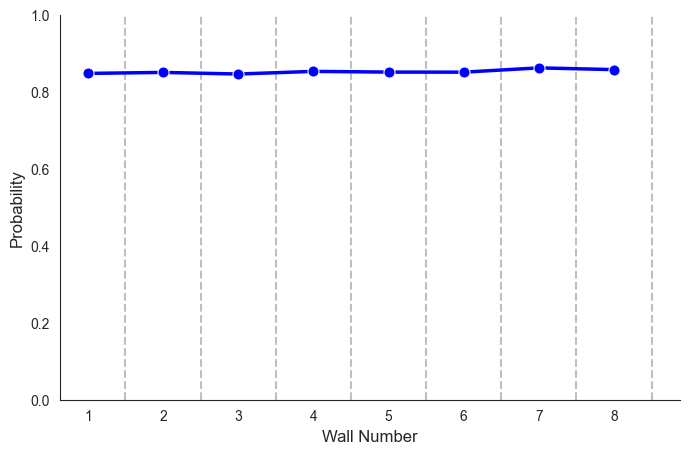

In [54]:
wall_numbers = np.arange(1,9)
wall_probabilities = wall_probabilities

# set seaborn style
sns.set_style("white", {"axes.grid": False})

# create figure and axis
plt.figure(figsize=(8, 5))

# plot vertical dashed grey lines for each categorical x value
for x in wall_numbers:
    plt.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

# plot the probability line with markers
sns.lineplot(x=wall_numbers, y=wall_probabilities, marker='o', markersize=8, linewidth=2.5, color="b")

# Customize labels and title
plt.xlabel("Wall Number", fontsize=12)
plt.ylabel("Probability", fontsize=12)
# plt.title("Probability of Choosing High by Wall Number", fontsize=14)

# set y-axis for probability
plt.ylim([0,1])

# adjust x-axis ticks to match categorical values
plt.xticks(wall_numbers)

# Remove top and right borders
sns.despine(top=True, right=True)

# show the plot
plt.show()

### By step penalty

In [55]:
sorted_sessions = sorted(zip(step_penalties, analysis_results.keys()), key=lambda x: x[0])

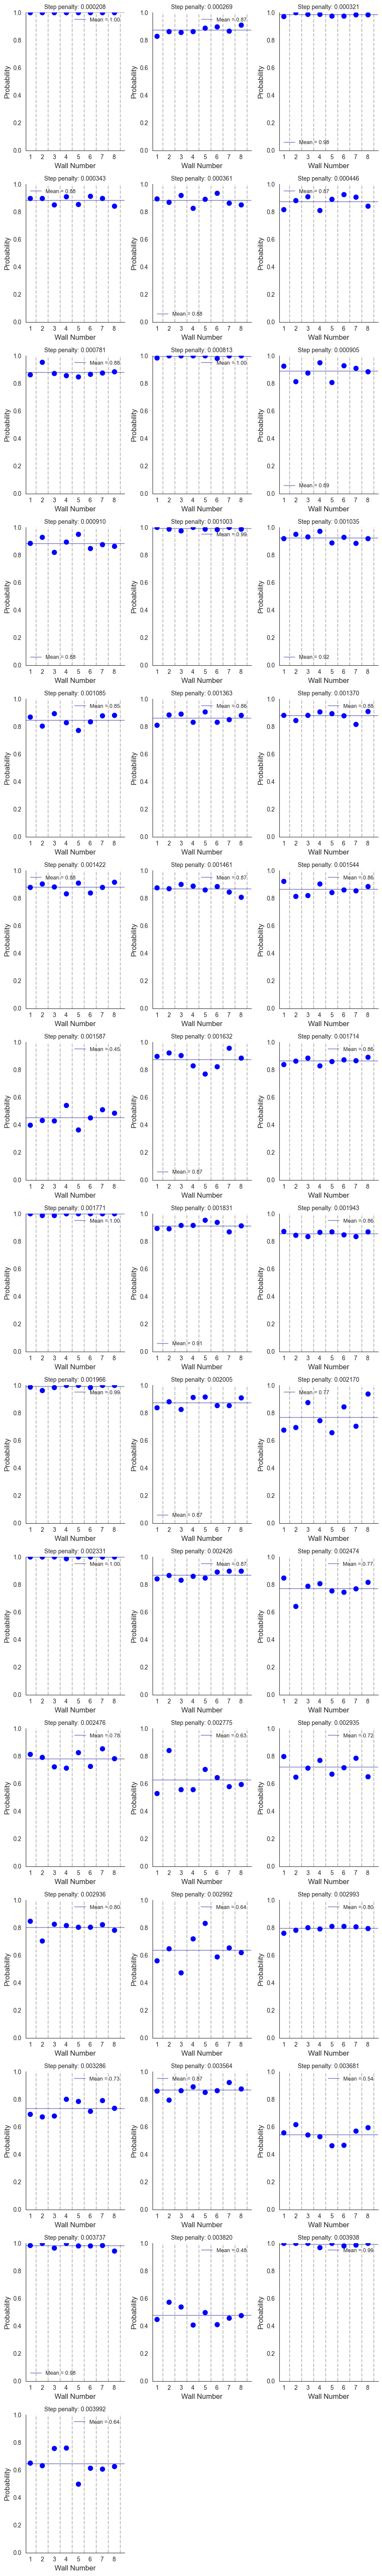

In [56]:
num_sessions = len(analysis_results)
num_cols = 3
num_rows = (num_sessions + num_cols - 1) // num_cols  # ceiling division
fig, axes = plt.subplots(num_rows, num_cols, figsize=(3*num_cols, 4*num_rows))

axes = axes.flatten()

for i, (penalty, session_id) in enumerate(sorted_sessions):
    ax = axes[i]
    
    wall_number_list = [analysis_results[session_id]['choice_data']['wall_numbers']]
    chose_high_list = [analysis_results[session_id]['choice_data']['chose_high']]

    wall_numbers = np.concatenate(wall_number_list).astype(int)
    chose_high = np.concatenate(chose_high_list)

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    # Print average P(High) across walls for each session
    avg_p_high = np.nanmean(wall_probabilities)
    #print(f"Average P(High) for session {session_id} (translation, turning costs: {thetas[0]:.6f}, {thetas[1]:.6f}): {avg_p_high:.3f}")

    wall_numbers_plot = np.arange(1,9)
    
    # set seaborn style
    sns.set_style("white", {"axes.grid": False})

    # plot vertical dashed grey lines for each categorical x value
    for x in wall_numbers_plot:
        ax.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

    # plot individual wall probabilities
    ax.scatter(
        wall_numbers_plot,
        wall_probabilities,
        color="blue",
        s=60,
        zorder=3
    )

    # plot average probability as a horizontal line
    ax.axhline(
        avg_p_high,
        color="darkblue",
        linestyle="-",
        linewidth=1.5,
        alpha=0.4,
        label=f"Mean = {avg_p_high:.2f}"
    )

    ax.legend(frameon=False, fontsize=9)

    # Customize labels and title
    ax.set_xlabel("Wall Number", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)
    ax.set_title(f"Step penalty: {penalty:.6f}", fontsize=10)

    # set y-axis for probability
    ax.set_ylim([0,1])

    # adjust x-axis ticks to match categorical values
    ax.set_xticks(wall_numbers_plot)

    # Remove top and right borders
    sns.despine(ax=ax, top=True, right=True)

for j in range(num_sessions, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### P(H) by step penalty

In [59]:
# Collect average P(High) for each session, sorted by step penalty
avg_p_high_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, analysis_results.keys()), key=lambda x: x[0]):
    #if session_id in [17, 23]:  # Exclude sessions 17 and 23
        #continue
    #wall_probabilities = analysis_results[session_id]['choice_data']['probability_chose_high']
    p_high_model = analysis_results[session_id]['choice_data']['p_high_model']
    sorted_penalties.append(penalty)
    avg_p_high_list.append(p_high_model)

In [63]:
max(sorted_penalties), min(sorted_penalties)

(0.003991561476141214, 0.00020832321024499834)

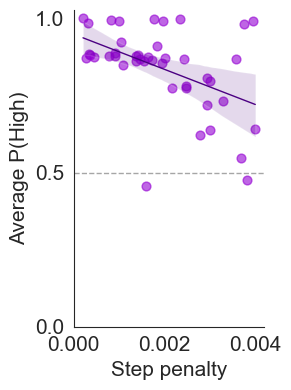

In [69]:
plt.figure(figsize=(3, 4))

sns.regplot(
    x=sorted_penalties,
    y=avg_p_high_list,
    scatter_kws={"color": "darkviolet", "s": 40, "alpha": 0.6},
    line_kws={"color": "indigo", "linewidth": 1},
    ci=95,
)

plt.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.7)

plt.xticks(np.arange(0, 0.004+0.0001, 0.002), fontsize=15)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=15)

plt.xlabel("Step penalty", fontsize=15)
plt.ylabel("Average P(High)", fontsize=15)

sns.despine()
plt.tight_layout()
plt.show()